# Download Dataset

In [ ]:
!pip install huggingface_hub

In [ ]:
dataset_path = '/content/drive/MyDrive/AI Image Detection/dataset'

In [ ]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id='NasrinImp/COCO_AI',
    repo_type="dataset",
    local_dir=dataset_path
)

# Load Dataset

In [ ]:
import os
import random
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io
from PIL import Image
import gc

In [ ]:
dataset_path = '/content/drive/MyDrive/AI Image Detection/dataset'

In [ ]:
model_path = '/content/drive/MyDrive/AI Image Detection/models'

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
FILE_LIST = [dataset_path + f"/data/train{i}.parquet" for i in range(13)]

In [ ]:
train_files = FILE_LIST[:7]
val_files   = FILE_LIST[7:10]
test_files  = FILE_LIST[10:]

In [ ]:
REAL_COL = 'coco_image'
AI_COLS = ['sd35_image', 'sd3_image', 'sd21_image', 'sdxl_image', 'dalle_image', 'midjourney_image']

In [ ]:
columns = [REAL_COL] + AI_COLS

In [ ]:
def preprocess_image(image_bytes):
    # 1. Decode image bytes to RGB
    img = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)

    # 2. Resize and Normalize
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0  # Scale pixel values to [0, 1]

    return img

In [ ]:
def make_generator(file_list):

    def generator():
        while True:
            random.shuffle(file_list)

            for file in file_list:
                df = pd.read_parquet(file, columns=columns)

                for _, row in df.iterrows():

                    # REAL
                    real_img = preprocess_image(row[REAL_COL]['bytes'])
                    if real_img is not None:
                        yield real_img, 0

                    # RANDOM AI
                    ai_col = random.choice(AI_COLS)
                    fake_img = preprocess_image(row[ai_col]['bytes'])
                    if fake_img is not None:
                        yield fake_img, 1

                del df
                gc.collect()

    return generator

In [ ]:
output_signature = (
    tf.TensorSpec(shape=(224, 224, 3), dtype=tf.float32),
    tf.TensorSpec(shape=(), dtype=tf.int32),
)

In [ ]:
train_dataset = tf.data.Dataset.from_generator(
    make_generator(train_files),
    output_signature=output_signature
)

train_dataset = train_dataset.shuffle(500).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
val_dataset = tf.data.Dataset.from_generator(
    make_generator(val_files),
    output_signature=output_signature
)

val_dataset = val_dataset.shuffle(500).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
steps_per_epoch = (771 * len(train_files) * 2) // BATCH_SIZE
validation_steps = (771 * len(val_files) * 2) // BATCH_SIZE
steps_per_epoch, validation_steps

(337, 144)

# Single Stream Models

**Custom CNN (Baseline Model)**

In [ ]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(224,224,3)),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,521 (91.20 MB)

 Trainable params: 23,907,521 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

In [ ]:
history = model.fit(
                train_dataset,
                validation_data=val_dataset,
                steps_per_epoch=steps_per_epoch,
                validation_steps=validation_steps,
                epochs=6
            )

Epoch 1/3
337/337 ━━━━━━━━━━━━━━━━━━━━ 154s 421ms/step - accuracy: 0.6218 - loss: 0.6875 - precision: 0.6110 - recall: 0.6701 - val_accuracy: 0.6790 - val_loss: 0.6391 - val_precision: 0.6778 - val_recall: 0.6816
Epoch 2/3
337/337 ━━━━━━━━━━━━━━━━━━━━ 133s 397ms/step - accuracy: 0.7007 - loss: 0.5826 - precision: 0.6890 - recall: 0.7306 - val_accuracy: 0.6851 - val_loss: 0.6111 - val_precision: 0.8023 - val_recall: 0.4880
Epoch 3/3
337/337 ━━━━━━━━━━━━━━━━━━━━ 137s 407ms/step - accuracy: 0.7576 - loss: 0.5025 - precision: 0.7534 - recall: 0.7665 - val_accuracy: 0.7088 - val_loss: 0.5769 - val_precision: 0.6662 - val_recall: 0.8408


In [ ]:
os.makedirs(model_path, exist_ok=True)
model.save(model_path + '/baseline.keras')

**ResNet50**

In [ ]:
base = tf.keras.applications.ResNet50(include_top=False, weights='imagenet', input_shape=(224,224,3))
base.trainable = True

x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
x = tf.keras.layers.Dense(128, activation='relu')(x)
output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs=base.input, outputs=output)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 23,796,993 (90.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

In [ ]:
history_resnet = model.fit(
                train_dataset,
                validation_data=val_dataset,
                steps_per_epoch=steps_per_epoch,
                validation_steps=validation_steps,
                epochs=3
            )

Epoch 1/3
337/337 ━━━━━━━━━━━━━━━━━━━━ 322s 735ms/step - accuracy: 0.7565 - loss: 0.5234 - precision: 0.7629 - recall: 0.7428 - val_accuracy: 0.5004 - val_loss: 0.7168 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/3
337/337 ━━━━━━━━━━━━━━━━━━━━ 245s 729ms/step - accuracy: 0.8178 - loss: 0.4037 - precision: 0.8198 - recall: 0.8141 - val_accuracy: 0.5608 - val_loss: 0.6919 - val_precision: 0.5434 - val_recall: 0.7772
Epoch 3/3
337/337 ━━━━━━━━━━━━━━━━━━━━ 251s 746ms/step - accuracy: 0.8472 - loss: 0.3547 - precision: 0.8594 - recall: 0.8318 - val_accuracy: 0.5024 - val_loss: 2.9564 - val_precision: 0.5008 - val_recall: 0.9991


In [ ]:
os.makedirs(model_path, exist_ok=True)
model.save(model_path + '/resnet50.keras')

**EfficientNetB0**

In [ ]:
base = tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224,224,3))
base.trainable = True

x = tf.keras.layers.GlobalAveragePooling2D()(base.output)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs=base.input, outputs=output)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,218,788 (16.09 MB)

 Trainable params: 4,174,205 (15.92 MB)

 Non-trainable params: 44,583 (174.16 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

In [ ]:
history = model.fit(
                train_dataset,
                validation_data=val_dataset,
                steps_per_epoch=steps_per_epoch,
                validation_steps=validation_steps,
                epochs=3
            )

Epoch 1/3
337/337 ━━━━━━━━━━━━━━━━━━━━ 282s 539ms/step - accuracy: 0.8151 - loss: 0.4597 - precision: 0.8179 - recall: 0.8091 - val_accuracy: 0.5263 - val_loss: 0.6927 - val_precision: 0.5172 - val_recall: 0.8953
Epoch 2/3
337/337 ━━━━━━━━━━━━━━━━━━━━ 170s 507ms/step - accuracy: 0.8815 - loss: 0.2963 - precision: 0.8862 - recall: 0.8764 - val_accuracy: 0.4985 - val_loss: 0.9594 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/3
337/337 ━━━━━━━━━━━━━━━━━━━━ 177s 526ms/step - accuracy: 0.9155 - loss: 0.2195 - precision: 0.9180 - recall: 0.9120 - val_accuracy: 0.5000 - val_loss: 1.0187 - val_precision: 0.5000 - val_recall: 0.9996


In [ ]:
os.makedirs(model_path, exist_ok=True)
model.save(model_path + '/EfficientNetB0.keras')

**VEGG16**

In [ ]:
base = tf.keras.applications.VGG16(include_top=False, weights='imagenet', input_shape=(224,224,3))
base.trainable = False

x = tf.keras.layers.Flatten()(base.output)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs=base.input, outputs=output)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

In [ ]:
history = model.fit(
                train_dataset,
                validation_data=val_dataset,
                steps_per_epoch=steps_per_epoch,
                validation_steps=validation_steps,
                epochs=3
            )

In [ ]:
os.makedirs(model_path, exist_ok=True)
model.save(model_path + '/VEGG16.keras')

# Dual Stream Models (Proposed Model)

In [ ]:
import keras

@keras.saving.register_keras_serializable()
def fft_layer(image):

    gray = tf.image.rgb_to_grayscale(image)
    gray = tf.squeeze(gray, axis=-1)

    fft = tf.signal.fft2d(tf.cast(gray, tf.complex64))
    fft_shift = tf.signal.fftshift(fft)

    magnitude = tf.math.log(tf.math.abs(fft_shift) + 1.0)

    # Normalize PER IMAGE
    mag_min = tf.reduce_min(magnitude, axis=[1,2], keepdims=True)
    mag_max = tf.reduce_max(magnitude, axis=[1,2], keepdims=True)

    magnitude = (magnitude - mag_min) / (mag_max - mag_min + 1e-7)

    magnitude = tf.expand_dims(magnitude, axis=-1)

    return magnitude

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# ================= BASIC BLOCK =================
def conv_block(x, filters, strides=1):
    x = layers.Conv2D(filters, (3,3), strides=strides, padding='same',
                      kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x

# ================= RESIDUAL BLOCK =================
def residual_block(x, filters):
    shortcut = x

    x = conv_block(x, filters)
    x = conv_block(x, filters)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), padding='same')(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

# ================= SE ATTENTION BLOCK =================
def se_block(x, reduction=8):
    filters = x.shape[-1]

    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(filters // reduction, activation='relu')(se)
    se = layers.Dense(filters, activation='sigmoid')(se)

    se = layers.Reshape((1,1,filters))(se)
    x = layers.Multiply()([x, se])
    return x


# ================= INPUT =================
input_img = layers.Input(shape=(224,224,3))

# ================= SPATIAL BRANCH =================
x1 = conv_block(input_img, 32)
x1 = conv_block(x1, 32)
x1 = layers.MaxPooling2D()(x1)

x1 = residual_block(x1, 64)
x1 = se_block(x1)
x1 = layers.MaxPooling2D()(x1)

x1 = residual_block(x1, 128)
x1 = se_block(x1)
x1 = layers.MaxPooling2D()(x1)

x1 = residual_block(x1, 256)
x1 = se_block(x1)

x1 = layers.GlobalAveragePooling2D()(x1)
x1 = layers.BatchNormalization()(x1)
x1 = layers.Dropout(0.5)(x1)


# ================= FFT BRANCH =================
fft = layers.Lambda(fft_layer)(input_img)

x2 = conv_block(fft, 32)
x2 = layers.MaxPooling2D()(x2)

x2 = residual_block(x2, 64)
x2 = layers.MaxPooling2D()(x2)

x2 = residual_block(x2, 128)
x2 = se_block(x2)

x2 = layers.GlobalAveragePooling2D()(x2)
x2 = layers.BatchNormalization()(x2)
x2 = layers.Dropout(0.5)(x2)


# ================= FUSION =================
combined = layers.concatenate([x1, x2])

# Deep classifier head
x = layers.Dense(256, activation='relu')(combined)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)

# ================= OUTPUT =================
output = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs=input_img, outputs=output)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 224, 224,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 224, 224,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 112, 112,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 112, 112,  │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 112, 112,  │      2,112 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 112, 112,  │          0 │ activation_3[0][… │
│                     │ 64)               │            │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 112, 112,  │          0 │ add[0][0]       

 Total params: 1,677,417 (6.40 MB)

 Trainable params: 1,673,385 (6.38 MB)

 Non-trainable params: 4,032 (15.75 KB)

In [ ]:
history = model.fit(
                train_dataset,
                validation_data=val_dataset,
                steps_per_epoch=steps_per_epoch,
                validation_steps=validation_steps,
                epochs=10
            )

Epoch 1/3
337/337 ━━━━━━━━━━━━━━━━━━━━ 287s 687ms/step - accuracy: 0.5780 - loss: 0.9059 - val_accuracy: 0.5508 - val_loss: 0.8038
Epoch 2/3
337/337 ━━━━━━━━━━━━━━━━━━━━ 232s 689ms/step - accuracy: 0.6816 - loss: 0.7469 - val_accuracy: 0.7316 - val_loss: 0.6500
Epoch 3/3
337/337 ━━━━━━━━━━━━━━━━━━━━ 257s 765ms/step - accuracy: 0.7075 - loss: 0.6936 - val_accuracy: 0.7372 - val_loss: 0.6367


In [ ]:
os.makedirs(model_path, exist_ok=True)
model.save(model_path + '/dualStreamModel2.keras')

# Evaluate

In [ ]:
model = tf.keras.models.load_model(model_path + '/dualStreamModel2.keras')
model.summary()

In [ ]:
# Create a test dataset
test_dataset = tf.data.Dataset.from_generator(
    make_generator(test_files),
    output_signature=output_signature
)
test_dataset = test_dataset.shuffle(500).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_steps = (771 * len(test_files) * 2) // BATCH_SIZE

In [ ]:
metrics = model.evaluate(test_dataset, steps=test_steps)
loss = metrics[0]
accuracy = metrics[1]
precision = metrics[2]
recall = metrics[3]

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")

144/144 ━━━━━━━━━━━━━━━━━━━━ 47s 275ms/step - accuracy: 0.7313 - loss: 0.6922 - precision: 0.7089 - recall: 0.7869
Test Loss: 0.6922
Test Accuracy: 0.7313
Test Precision: 0.7089
Test Recall: 0.7869


In [ ]:
def make_test_generator(file_list):

    def generator():
        for file in file_list:
            df = pd.read_parquet(file, columns=[REAL_COL] + AI_COLS)

            for _, row in df.iterrows():

                real_img = preprocess_image(row[REAL_COL]['bytes'])
                if real_img is not None:
                    yield real_img, 0

                for col in AI_COLS:
                    fake_img = preprocess_image(row[col]['bytes'])
                    if fake_img is not None:
                        yield fake_img, 1

    return generator

In [ ]:
test_dataset = tf.data.Dataset.from_generator(
    make_test_generator(test_files),
    output_signature=output_signature
)

test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
all_predictions = model.predict(test_dataset, steps=test_steps, verbose=1)
y_pred = (all_predictions > 0.5).astype(int).flatten()

144/144 ━━━━━━━━━━━━━━━━━━━━ 37s 236ms/step


In [ ]:
y_true = []

for _, labels in test_dataset.take(test_steps):
    y_true.extend(labels.numpy())

y_true = np.array(y_true)

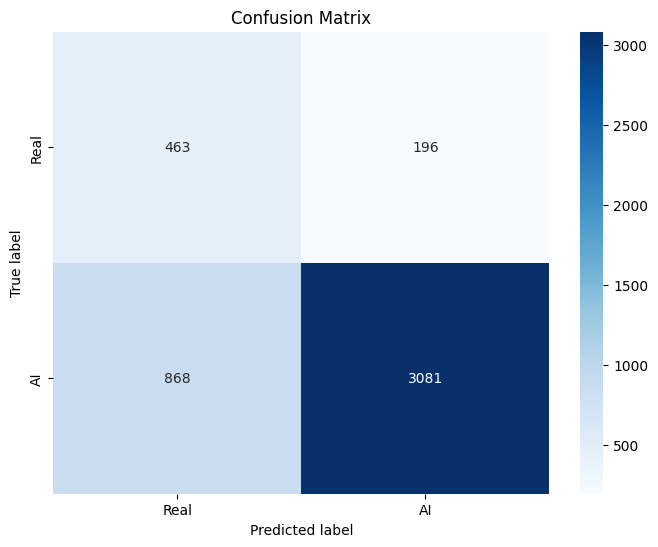

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='g',
    cmap='Blues',
    xticklabels=['Real', 'AI'],
    yticklabels=['Real', 'AI']
)

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()